# Лабораторная работа №3
Работа с видеопотоком

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Загрузим изображение

Видео успешно загружено!


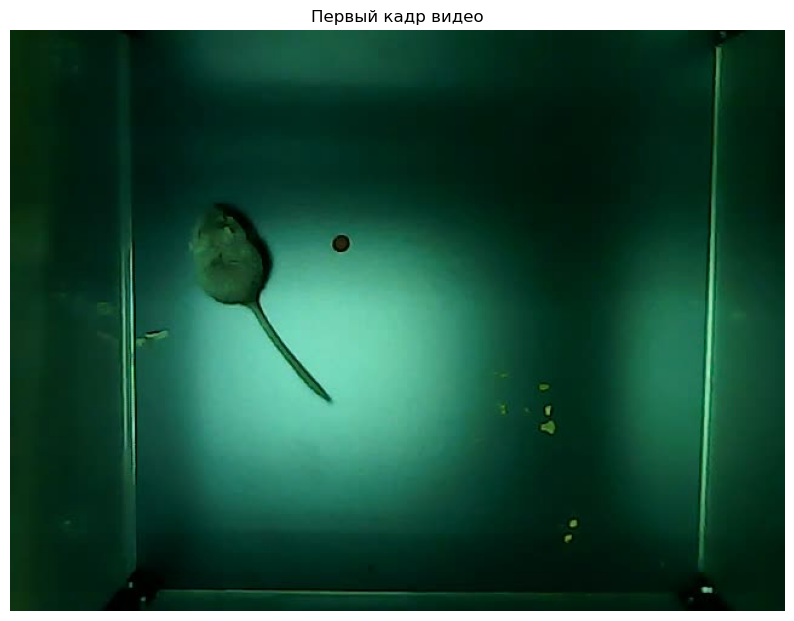

In [2]:
# Загружаем видео для обработки
cap = cv2.VideoCapture("mouse_1.avi")

# Проверяем, загрузилось ли видео
if not cap.isOpened():
    print("Ошибка: не удалось загрузить видео")
else:
    print("Видео успешно загружено!")
    success, img3=cap.read()
    if success:
        img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
        
        # Отображаем изображение
        plt.figure(figsize=(10, 8))
        plt.imshow(img3_rgb)
        plt.axis('off')  # Скрываем оси
        plt.title('Первый кадр видео')
        plt.show()
    else:
        print("Не удалось прочитать кадр")


Решим поставленную задачу следующим образом. Разделим Видеопоток покадрово, усредним, а после удалим фон (можем удалить так как мышь двигается на постоянном фоне), бинаризуем изображение и найдем центр масс мыши. Далее, составим траекторию движения мыши убрав шум и нулевые значения.

Переведем видеопоток в оттенки серого для упрощения работы с ними

In [3]:
i=1
success = True
imgs = []
print(i)
while (success == True):
  print(i)
  success, img = cap.read()
  img_grey=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  imgs.append(img_grey) #Добавляем кадр в список
  i=i+1

1
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

<class 'cv2.error'>: OpenCV(4.11.0) /home/runner/work/pyodide-recipes/pyodide-recipes/packages/opencv-python/build/opencv-python-4.11.0.86/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [4]:
imgs[4000] #Проверяем количество кадров (есть ли 4000 кадр)

array([[79, 78, 77, ..., 60, 59, 59],
       [75, 75, 74, ..., 60, 59, 59],
       [71, 71, 72, ..., 60, 59, 59],
       ...,
       [83, 83, 83, ..., 54, 54, 54],
       [83, 83, 83, ..., 54, 54, 54],
       [83, 83, 83, ..., 54, 54, 54]], shape=(480, 640), dtype=uint8)

In [5]:
len(imgs)

6075

Поскольку фон остается статичным, оптимальным подходом к решению задачи является построение модели фона. Начнем с реализации простейшего метода — усреднения фона. В реальных условиях этот метод обычно неприменим, так как требует накопления информации о всех кадрах для усреднения пикселей. Однако в нашем конкретном примере такие данные доступны изначально, что позволяет использовать данный подход.

In [6]:
def sr_mod_fon(arr_image): #функция среднего фона
    mod_fon = np.zeros(arr_image[1].shape, dtype='uint8')
    sum_arr = np.zeros(arr_image[0].shape, dtype=np.float64)
    num_frames = len(arr_image) - 10
    
    for k in range(len(arr_image) - 10):
        image = arr_image[k]
        for i in range(len(image)):
            for j in range(len(image[i])):
                sum_arr[i, j] = sum_arr[i, j] + image[i, j]
        print(k)
    
    sum_arr = sum_arr / num_frames
    return sum_arr

In [7]:
amt=sr_mod_fon(imgs) # Проверка

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

Округлим значения пикселей. Для этого используем np требуемый формат изображения, а именно np.uint8

In [8]:
new=np.uint8(amt)

Бинаризируем картинку для поиска центра масс

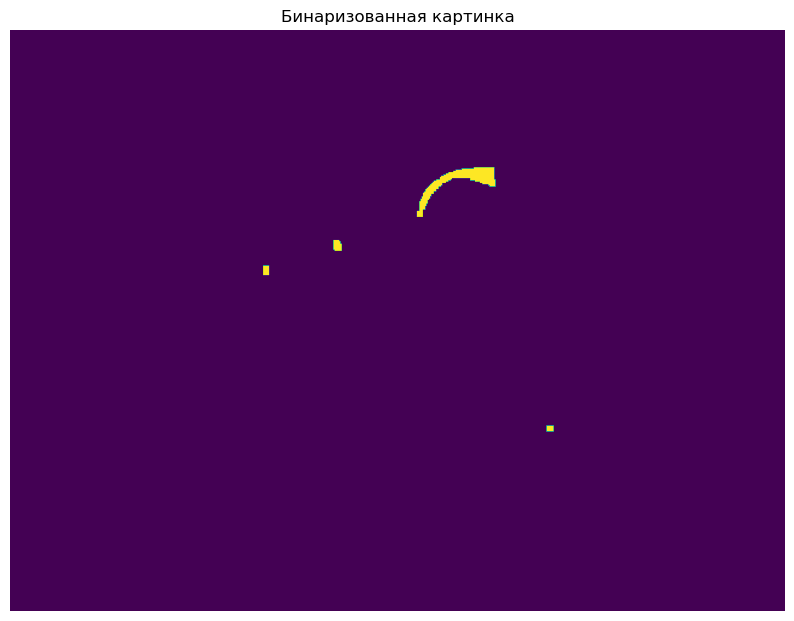

In [9]:
diff_image=cv2.addWeighted(imgs[2005],1,new,-1,0) #Вычитание фона
ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY) # Бинаризация
thresh=cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((5,5),np.uint8), iterations=1) # Открытие/Удаление шума
thresh=cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), iterations=1) # Закрытие

# Отображаем изображение
plt.figure(figsize=(10, 8))
plt.imshow(thresh)
plt.axis('off')  # Скрываем оси
plt.title('Бинаризованная картинка')
plt.show()

In [10]:
mu=cv2.moments(thresh) #Вычисление моментов бинарного изображения
mc = (mu['m10'] / (mu['m00'] + 1e-5), mu['m01'] / (mu['m00'] + 1e-5)) #вычисление центра масс
mc

(357.1491002390671, 141.30719793632204)

In [11]:
image_test = imgs[2005].copy()
cv2.circle(image_test,(int(mc[0]), int(mc[1])), 5, (0,0,255), -1) #Рисуем красный круг в центре масс мфшки

array([[69, 69, 69, ..., 57, 57, 57],
       [70, 70, 69, ..., 57, 57, 57],
       [71, 71, 70, ..., 57, 57, 57],
       ...,
       [79, 79, 79, ..., 50, 50, 50],
       [79, 79, 79, ..., 50, 50, 50],
       [79, 79, 79, ..., 50, 50, 50]], shape=(480, 640), dtype=uint8)

In [12]:
def mod_fon (arr_image): #Вычислим центр масс для массива
  mod_fon = np.zeros(arr_image[1].shape, dtype='uint8') # Создаем модель фона
  mom=[None]*len(arr_image) #Создаем пустой массив
  for k in range(len(arr_image)-11): # Обозначаем мимнимальный размер
    mod_fon=cv2.addWeighted(arr_image[k],0.5,mod_fon,0.5,0) # Обновление фона
    diff_image=cv2.addWeighted(arr_image[k],1,mod_fon,-1,0) # Вычитание фона
    ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY) # Бинаризация
    mu=cv2.moments(thresh)
    mom[k]=(mu['m10'] / (mu['m00'] + 1e-5), mu['m01'] / (mu['m00'] + 1e-5)) # Определение центра масс
    if(mom[k][0]==0 and mom[k][1]==0): # Убираем нулевые центры (берем предыдущие)
      mom[k]=mom[k-1]
    if(k!=0):
      if((mom[k][0]-mom[k-1][0])>30 or (mom[k][1]-mom[k-1][1])>30):  # Фильтруем скачки
        mom[k]=mom[k-1]
  return mom

In [13]:
data=mod_fon(imgs)
data[10][1]

166.99999345098064

In [14]:
data

[(314.3431410181802, 260.2804498866953),
 (313.23384220273596, 269.0604104245666),
 (267.899428097001, 277.581118321306),
 (273.8163263114715, 266.5714283580861),
 (271.9999984761905, 198.42857031692677),
 (271.9999984761905, 198.42857031692677),
 (271.9999984761905, 198.42857031692677),
 (271.9999984761905, 198.42857031692677),
 (203.9999920000003, 166.99999345098064),
 (203.9999920000003, 166.99999345098064),
 (203.9999920000003, 166.99999345098064),
 (203.9999920000003, 166.99999345098064),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (179.99999294117674, 152.99999400000024),
 (190.9999925098042, 161.999

In [15]:
X=imgs[0]
X_rgb = cv2.cvtColor(X, cv2.COLOR_BGR2RGB)

In [16]:
len(data)

6075

In [17]:
D1=[None]*len(data)
D2=[None]*len(data)
for k in range(len(data)-10):
  print(k)
  D1[k] = data[k][0]
  D2[k] = data[k][1]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

<class 'TypeError'>: 'NoneType' object is not subscriptable

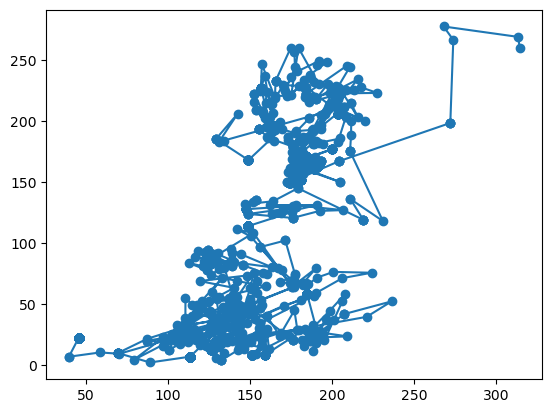

In [18]:
plt.plot(D1, D2, marker='o')